In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from sklearn.ensemble import IsolationForest, AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score

# Load processed dataset

In [2]:
X_train = pd.read_csv('FIFA_Binary_Cleaned_Final_Train.csv')
X_test = pd.read_csv('FIFA_Binary_Cleaned_Final_Test.csv')

In [3]:
threshold = X_train['international_reputation'].median()
y_train = np.where(X_train['international_reputation'] > threshold, 1, 0)
y_test = np.where(X_test['international_reputation'] > threshold, 1, 0)

In [4]:
X_train = X_train.drop(columns=['international_reputation'])
X_test = X_test.drop(columns=['international_reputation'])

# Anomaly Detection methods

In [5]:
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train)
X_train_pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])

In [6]:
iso = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso.fit_predict(X_train_pca_df)
iso_anoms = (iso_preds == -1)

In [7]:
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_train_pca_df)
dist, _ = knn.kneighbors(X_train_pca_df)
knn_thresh = np.percentile(dist[:, -1], 95)
knn_anoms = dist[:, -1] > knn_thresh

In [8]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_anoms = (lof.fit_predict(X_train_pca_df) == -1)

In [9]:
total_anomalies = iso_anoms.astype(int) + knn_anoms.astype(int) + lof_anoms.astype(int)
mask = total_anomalies < 2

In [10]:
X_train_refined = X_train[mask].reset_index(drop=True)
y_train_refined = y_train[mask]

In [11]:
print(f"Original rows: {len(X_train)} | Refined rows: {len(X_train_refined)}")

Original rows: 14622 | Refined rows: 13987


# Visualising anomalies

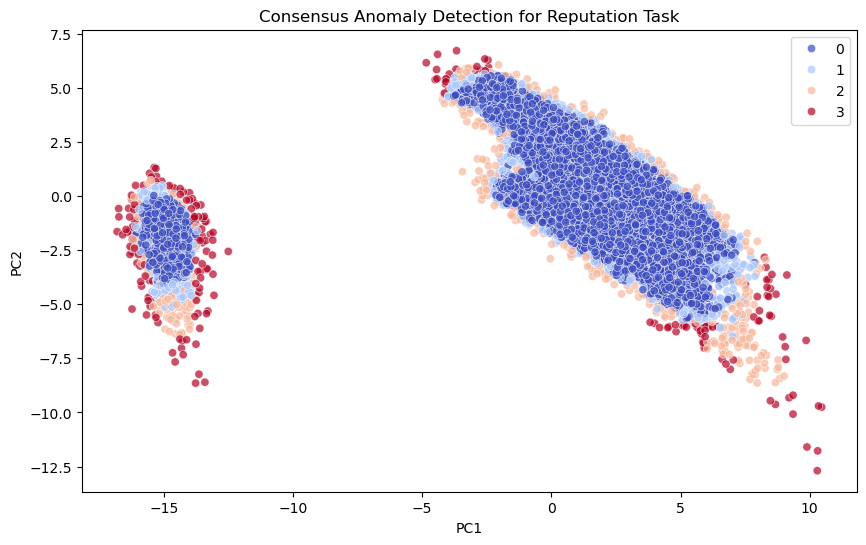

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_pca_df.iloc[:, 0], y=X_train_pca_df.iloc[:, 1], 
                hue=total_anomalies, palette='coolwarm', alpha=0.7)
plt.title('Consensus Anomaly Detection for Reputation Task')
plt.show()

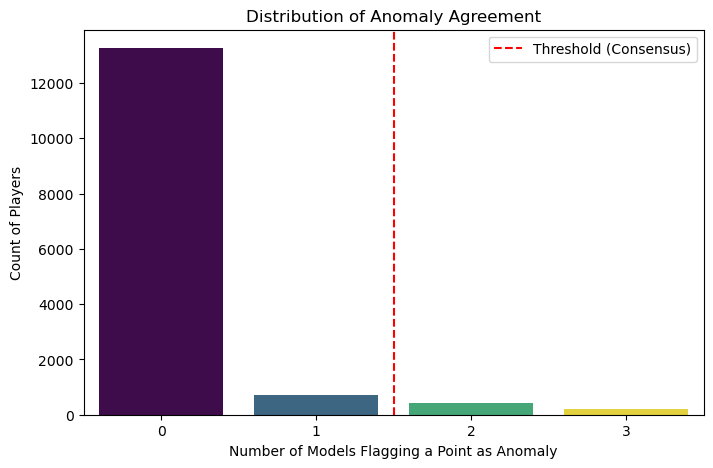

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(x=total_anomalies, hue=total_anomalies, palette='viridis', legend=False)

plt.axvline(x=1.5, color='red', linestyle='--', label='Threshold (Consensus)')
plt.title('Distribution of Anomaly Agreement')
plt.xlabel('Number of Models Flagging a Point as Anomaly')
plt.ylabel('Count of Players')
plt.legend()
plt.show()

# Recursive Feature Elimination (RFE)

In [14]:

X_train_iter = X_train_refined.copy()
X_test_iter = X_test.copy()
remaining_features = X_train_iter.columns.tolist()

best_accuracy = 0
best_features_list = []
history = []

print(f"{'Features':<10} | {'Accuracy':<10} | {'Removed Feature'}")
print("-" * 55)

while len(remaining_features) > 1:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=50,
        random_state=42
    )
    model.fit(X_train_iter, y_train_refined)
    y_pred = model.predict(X_test_iter)
    acc = accuracy_score(y_test, y_pred)
    
    history.append((len(remaining_features), acc))
    if acc > best_accuracy:
        best_accuracy = acc
        best_features_list = remaining_features.copy()

    importances = model.feature_importances_
    least_important_idx = np.argmin(importances)
    removed_feature = remaining_features[least_important_idx]
    
    print(f"{len(remaining_features):<10} | {acc:<10.4f} | {removed_feature}")
    
    remaining_features.remove(removed_feature)
    X_train_iter = X_train_iter[remaining_features]
    X_test_iter = X_test_iter[remaining_features]

print(f"\n✅ Optimization Finished! Best Accuracy: {best_accuracy:.4f}")

Features   | Accuracy   | Removed Feature
-------------------------------------------------------
74         | 0.9489     | gk_diving
73         | 0.9461     | loaned_from
72         | 0.9461     | num_positions
71         | 0.9458     | gk_positioning
70         | 0.9461     | gk_kicking
69         | 0.9461     | preferred_foot_Right
68         | 0.9486     | gk_speed
67         | 0.9540     | skill_moves
66         | 0.9519     | gk_handling
65         | 0.9519     | nation_position
64         | 0.9510     | gk_reflexes
63         | 0.9513     | body_type
62         | 0.9489     | player_tags_count
61         | 0.9530     | shooting
60         | 0.9508     | weak_foot
59         | 0.9480     | work_rate
58         | 0.9540     | defending
57         | 0.9447     | team_position
56         | 0.9510     | dribbling
55         | 0.9502     | goalkeeping_kicking
54         | 0.9478     | goalkeeping_positioning
53         | 0.9478     | joined_month
52         | 0.9524     | goalkeeping_

# Model comparaison before anomaly detection and after

In [15]:

baseline_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=12, random_state=42),
    n_estimators=50, random_state=42
)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred_baseline)

accuracy_after = best_accuracy
print("\n" + "="*50)
print("             MODEL PERFORMANCE RESULTS")
print("="*50)
print(f"The Model accuracy before anomaly detection: {accuracy_before:.16f}")
print(f"After Removal of anomalies: {accuracy_after:.4f}")
print("="*50)

print(f"Optimal Number of Features: {len(history)}")
print(f"Improvement Gain: {((accuracy_after - accuracy_before) / accuracy_before) * 100:.2f}%")


             MODEL PERFORMANCE RESULTS
The Model accuracy before anomaly detection: 0.9573304157549234
After Removal of anomalies: 0.9557
Optimal Number of Features: 73
Improvement Gain: -0.17%


# Confusion matrix

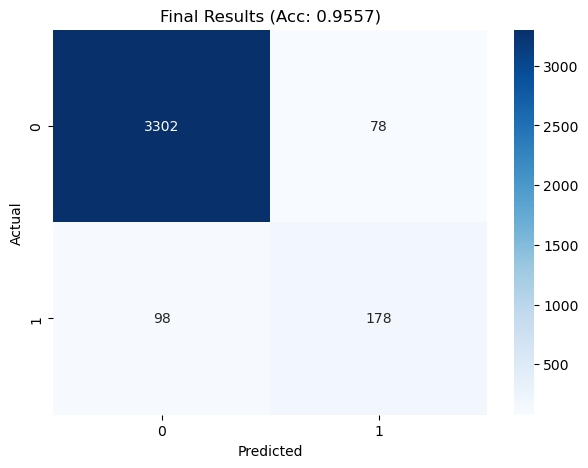


Final Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3380
           1       0.70      0.64      0.67       276

    accuracy                           0.95      3656
   macro avg       0.83      0.81      0.82      3656
weighted avg       0.95      0.95      0.95      3656



In [16]:
final_model = AdaBoostClassifier(random_state=42)
final_model.fit(X_train_refined[best_features_list], y_train_refined)
final_preds = final_model.predict(X_test[best_features_list])

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues')
plt.title(f"Final Results (Acc: {best_accuracy:.4f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nFinal Classification Report:")
print(classification_report(y_test, final_preds))

# Model comparaison on refined dataset to identify better accurcy

In [17]:
models = {
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=100,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        max_depth=15, 
        random_state=42
    )
}

results = []

print("--- Model Performance Comparison ---")

for name, model in models.items():
    model.fit(X_train_refined[best_features_list], y_train_refined)
    
    y_pred = model.predict(X_test[best_features_list])
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })
    
    print(f"\n{name} Results:")
    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))


comparison_df = pd.DataFrame(results).set_index("Model")
print("\nFinal Comparison Table:")
print(comparison_df)

--- Model Performance Comparison ---

AdaBoost Results:
Accuracy: 95.68%
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3380
           1       0.74      0.65      0.69       276

    accuracy                           0.96      3656
   macro avg       0.86      0.82      0.84      3656
weighted avg       0.95      0.96      0.96      3656


Random Forest Results:
Accuracy: 95.57%
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3380
           1       0.79      0.57      0.66       276

    accuracy                           0.96      3656
   macro avg       0.88      0.78      0.82      3656
weighted avg       0.95      0.96      0.95      3656


Final Comparison Table:
               Accuracy  Precision    Recall
Model                                       
AdaBoost       0.956783   0.743802  0.652174
Random Forest  0.955689   0.785000  0.568841


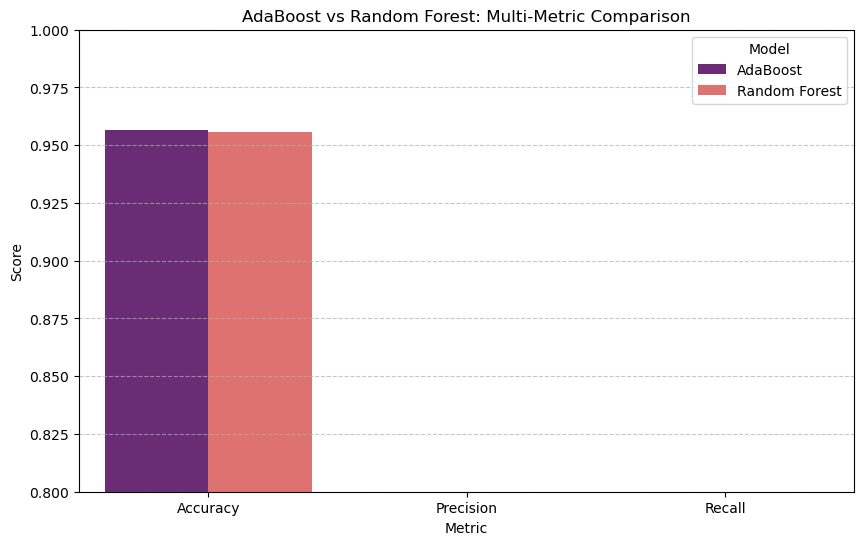

In [18]:
comparison_df.reset_index(inplace=True)
melted_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x='Metric', y='Score', hue='Model', palette='magma')
plt.title('AdaBoost vs Random Forest: Multi-Metric Comparison')
plt.ylim(0.8, 1.0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

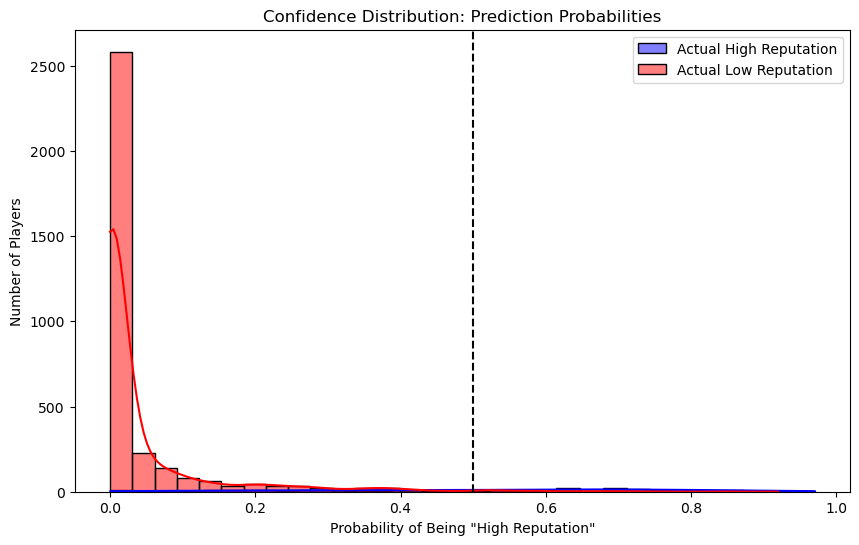

In [22]:
from sklearn.ensemble import RandomForestClassifier

refined_rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
refined_rf.fit(X_train_refined[best_features_list], y_train_refined)

y_probs = refined_rf.predict_proba(X_test[best_features_list])[:, 1]

plt.figure(figsize=(10, 6))
sns.histplot(y_probs[y_test == 1], color='blue', label='Actual High Reputation', kde=True, bins=30)

sns.histplot(y_probs[y_test == 0], color='red', label='Actual Low Reputation', kde=True, bins=30)

plt.axvline(x=0.5, color='black', linestyle='--')
plt.title('Confidence Distribution: Prediction Probabilities')
plt.xlabel('Probability of Being "High Reputation"')
plt.ylabel('Number of Players')
plt.legend()
plt.show()

# Feature importance and shap based on best model

Calculating SHAP values... (this may take a minute)


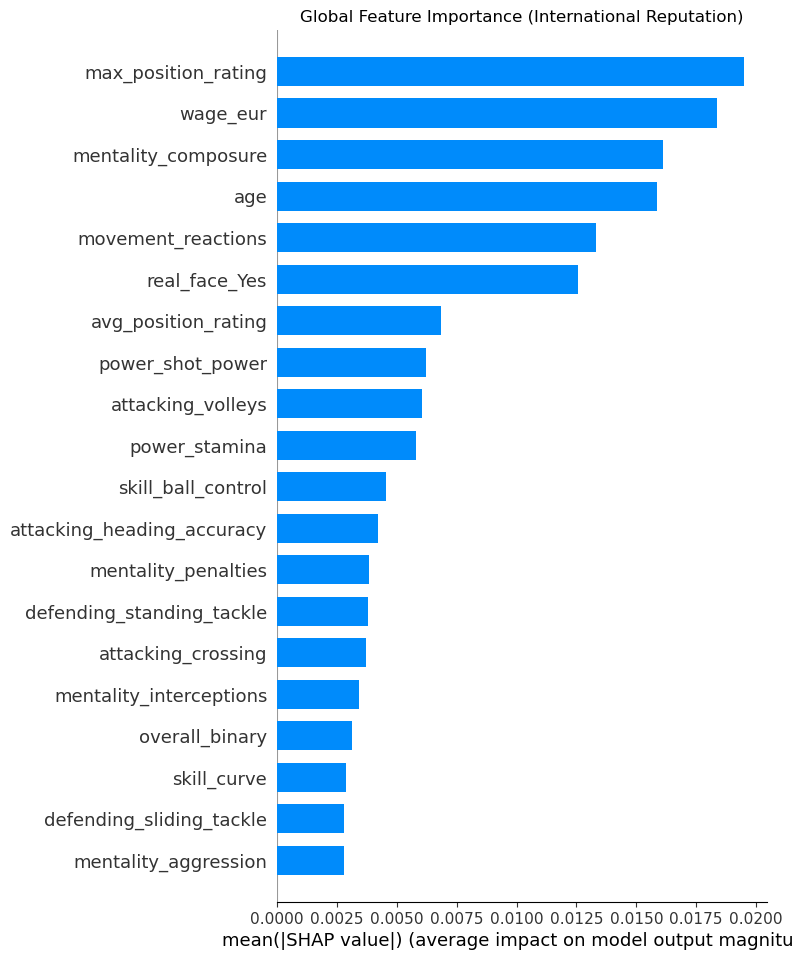

In [24]:
from sklearn.ensemble import RandomForestClassifier

refined_rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
refined_rf.fit(X_train_refined[best_features_list], y_train_refined)

print("Calculating SHAP values... (this may take a minute)")

X_test_subset = X_test[best_features_list]

explainer = shap.TreeExplainer(refined_rf)
shap_values = explainer.shap_values(X_test_subset)

if isinstance(shap_values, list):
    target_shap = shap_values[1] # Class 1 (High International Reputation)
else:
    target_shap = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(target_shap, X_test_subset, plot_type="bar", show=False)
plt.title("Global Feature Importance (International Reputation)")
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.savefig('shap_feature_importance_bar.png', bbox_inches='tight')
plt.show()

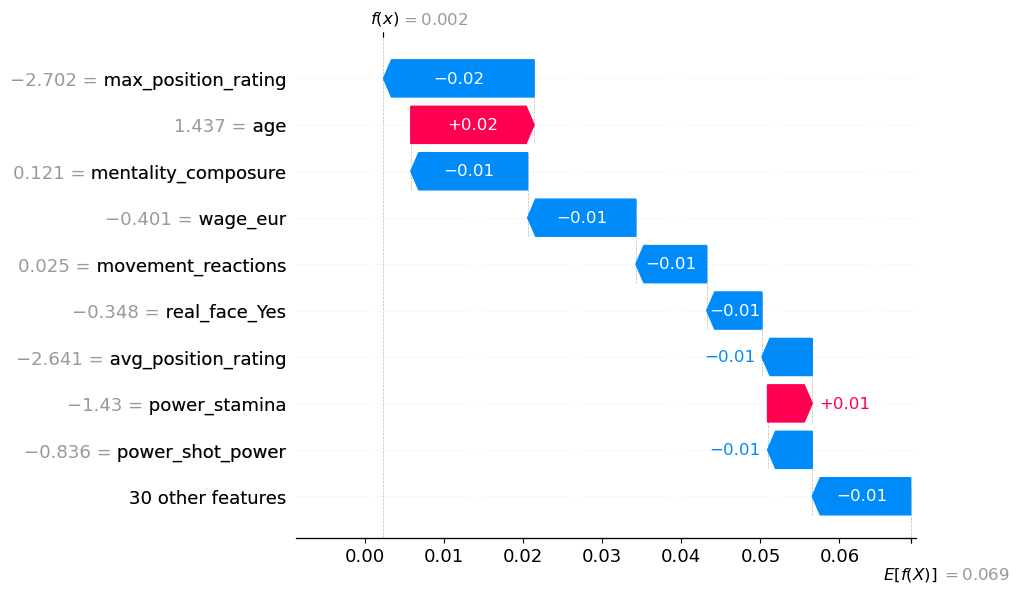

In [25]:
try:
    if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1:
        base_val = explainer.expected_value[1]
    else:
        base_val = explainer.expected_value

    plt.figure()
    exp = shap.Explanation(values=target_shap[0],
                           base_values=base_val,
                           data=X_test_subset.iloc[0],
                           feature_names=X_test_subset.columns)
    shap_values_waterfall = shap.plots.waterfall(exp, show=False)
    plt.savefig('shap_waterfall.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Waterfall plot failed: {e}")

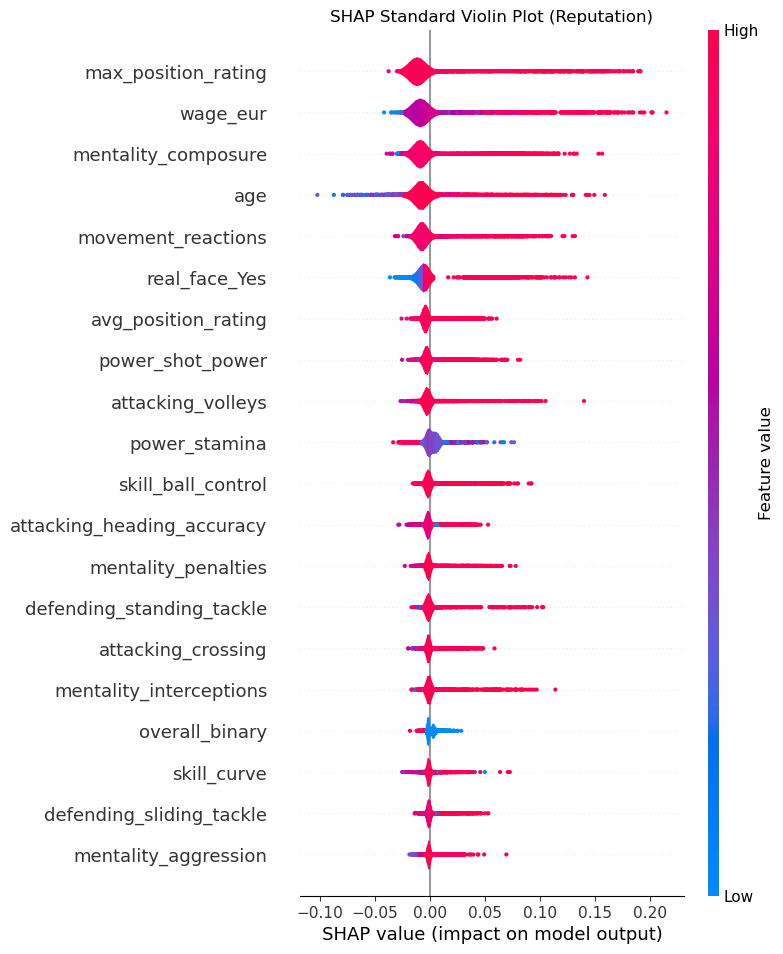

In [26]:
plt.figure()
shap.summary_plot(target_shap, X_test_subset, plot_type="violin", show=False)
plt.title("SHAP Standard Violin Plot (Reputation)")
plt.savefig('shap_violin_standard.png', bbox_inches='tight')
plt.show()